In [151]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [153]:
data = pd.read_csv("data/data.csv")

In [155]:
data.head()

,VideoAnalysis: Time (s),VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s)
0,0.595,2.315135,7.353513,12.297397,26.324326
1,0.629,2.751815,8.270541,11.751259,25.351348
2,0.662,3.101159,9.100233,11.452038,23.913709
3,0.695,3.494172,9.842590,11.506013,22.579152
4,0.729,3.887184,10.584946,11.161415,21.924713


### Since for calculation purpose it is easier to start at time = 0 
### we are going to subtract t initial from all the time values

In [158]:
data['VideoAnalysis: Time (s)'] -= data['VideoAnalysis: Time (s)'][0]

In [159]:
data.head()

,VideoAnalysis: Time (s),VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s)
0,0.000,2.315135,7.353513,12.297397,26.324326
1,0.034,2.751815,8.270541,11.751259,25.351348
2,0.067,3.101159,9.100233,11.452038,23.913709
3,0.100,3.494172,9.842590,11.506013,22.579152
4,0.134,3.887184,10.584946,11.161415,21.924713


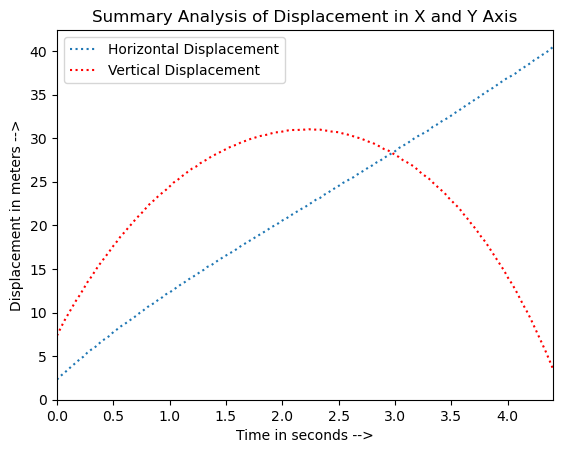

In [161]:
fig, ax = plt.subplots()
ax.set_title("Summary Analysis of Displacement in X and Y Axis")
ax.set_xlabel("Time in seconds -->")
ax.set_ylabel("Displacement in meters -->")
ax.plot(data.iloc[:, 0], data.iloc[:, 1], label = "Horizontal Displacement", linestyle=":")
ax.plot(data.iloc[:, 0], data.iloc[:, 2], label = "Vertical Displacement", linestyle=":", c="r")

# Minimum and Maximum element of time set as the x axis limit
ax.set_xlim(min(data['VideoAnalysis: Time (s)']), max(data['VideoAnalysis: Time (s)']))
ax.set_ylim(bottom = 0)
ax.legend()
pass


In [163]:
data

,VideoAnalysis: Time (s),VideoAnalysis: X (m),VideoAnalysis: Y (m),VideoAnalysis: X Velocity (m/s),VideoAnalysis: Y Velocity (m/s)
0,0.000,2.315135,7.353513,12.297397,26.324326
1,0.034,2.751815,8.270541,11.751259,25.351348
2,0.067,3.101159,9.100233,11.452038,23.913709
3,0.100,3.494172,9.842590,11.506013,22.579152
4,0.134,3.887184,10.584946,11.161415,21.924713
...,...,...,...,...,...
128,4.271,39.214610,7.484517,8.624977,-28.012708
129,4.304,39.520287,6.523820,8.625520,-28.737792
130,4.338,39.782295,5.563124,8.935645,-29.505061
131,4.371,40.087971,4.558759,10.082347,-30.571791


### Measuring the cone in the lab we found out the height to be 1.22 meters and measuring the cone in Logger Pro we got 1.31 meters as the height

### The uncertainty is \(1.31 - 1.22\) meters = 0.5 meters

### The uncertainity of the ball movemet is approximatex 0.5 meters because on each frame change the ball tends to move around 0.5 meters.
### Adding these two we get (0.5 + 0.5) meters = 1 meters


##

$$
\text{total uncertainty in y = 1 meters}
$$

### For the uncertainity in the x axis we can take the time difference between two measurments as an uncertainity and the logger
### which is 0.03 seconds

In [377]:
y_uncertainity = 0.5 + 0.5
x_uncertainity = 0.3

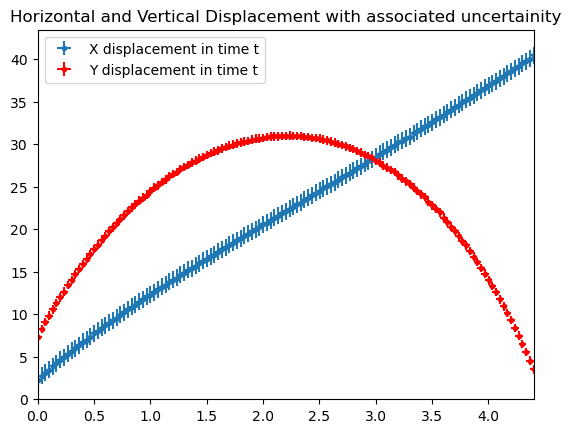

In [379]:
fig, ax = plt.subplots()
ax.set_title("Horizontal and Vertical Displacement with associated uncertainity")
ax.errorbar(data.iloc[:, 0], data.iloc[:, 1], label = "X displacement in time t", yerr = 1, xerr = 0.034,fmt='.')
ax.errorbar(data.iloc[:, 0], data.iloc[:, 2], label = "Y displacement in time t", yerr = 0.5, xerr = 0.034,fmt='.', c = "red")
ax.legend()
ax.set_xlim(min(data.iloc[:, 0]), max(data.iloc[:, 0]))
ax.set_ylim(bottom = 0)
ax.legend()
pass



## Dominant Source of uncertainity: 
### The dominant source of uncertainity is our eyes getting not tracking the exact ball movement

In [382]:
# model used to fit the velocity along y axis
linear_model = lambda x, A, B: x * A + B
quad_model = lambda x, A, B, C: A * x**2 + B * x + C

In [384]:
linear_parameters, cov = curve_fit(linear_model, data["VideoAnalysis: Time (s)"], data["VideoAnalysis: X (m)"], sigma=(np.ones(len(data))) * y_uncertainity)
quadratic_parameters, cov = curve_fit(quad_model, data["VideoAnalysis: Time (s)"], data["VideoAnalysis: Y (m)"], sigma=(np.ones(len(data))) * y_uncertainity)

In [386]:
print("Linear parameters:", linear_parameters)
print("Quadratic parameters:", quadratic_parameters)
v_x = linear_parameters[0]
x_intercept = linear_parameters[1]
v_y = quadratic_parameters[1]
y_intercept = quadratic_parameters[2]


Linear parameters: [8.34050841 3.62377926]
Quadratic parameters: [-5.11719818 22.07262371  7.56490506]


### Physics Connection to Parameters

- The linear fit shows a constant velocity of **v_x** m/s and an initial position of **x_intercept** meters.
- The quadratic fit suggests an initial vertical velocity of **v_y** m/s and an initial height of **y_intercept** meter

$$
\text{slope of horizontal displacement = 8.3 (m/s) +/- 1 (m/s)}
$$

$$
\text{X Intercecpt = 3.6 (m/s) +/- 1 (m/s)}
$$

$$
\text{slope of vertical displacement = 22.0 (m/s) +/- 1 (m/s)}
$$
$$
\text{Y Interept = 7.6 (m/s) +/- 1 (m/s)}
$$


### The angle of the launch is give by 

$$
\theta = \tan^{-1} \left( \frac{v_y}{v_x} \right)
$$

In [391]:
theta = np.arctan(v_y / v_x)
theta = np.degrees(theta)
print("Angle =", theta)

Angle = 69.30009326532154


### Since the dominant source of the uncertainity is relativly very large compared to other uncertainities we would only consider that in our estimations

$$
\text{Angle of launch =69.3 (degree) +/- 1 (degree)}
$$


### We cana get the range by
$$
R = \frac{v_0^2 \sin(2\theta)}{g}
$$

In [404]:
v_inital = np.sqrt(v_x ** 2 + v_y**2)
gravity = 9.81
range = ((v_inital)**2 * np.sin(np.radians(2 * theta)) / gravity) + x_intercept
print(f"Range = {range:.2g}")


Range = 41


## The calculated range is 
$$ 
\text{Range = 41 +/- 1 meters}
$$

## Comparison between logger pro resluts and our results in python:

In logger pro by fitting the curve fit we got the slope of the horizontal displacement to be 8.4 and the intercept to be -1.4 meter.
For the Y motion we got the slope of the vertical displacement to be 22.4 meters/second and the intercept to be -7.4 meters.
For the range the distance between where the ball was launced and where it landed was 39 meters.

The results seem to be close to our measurments.


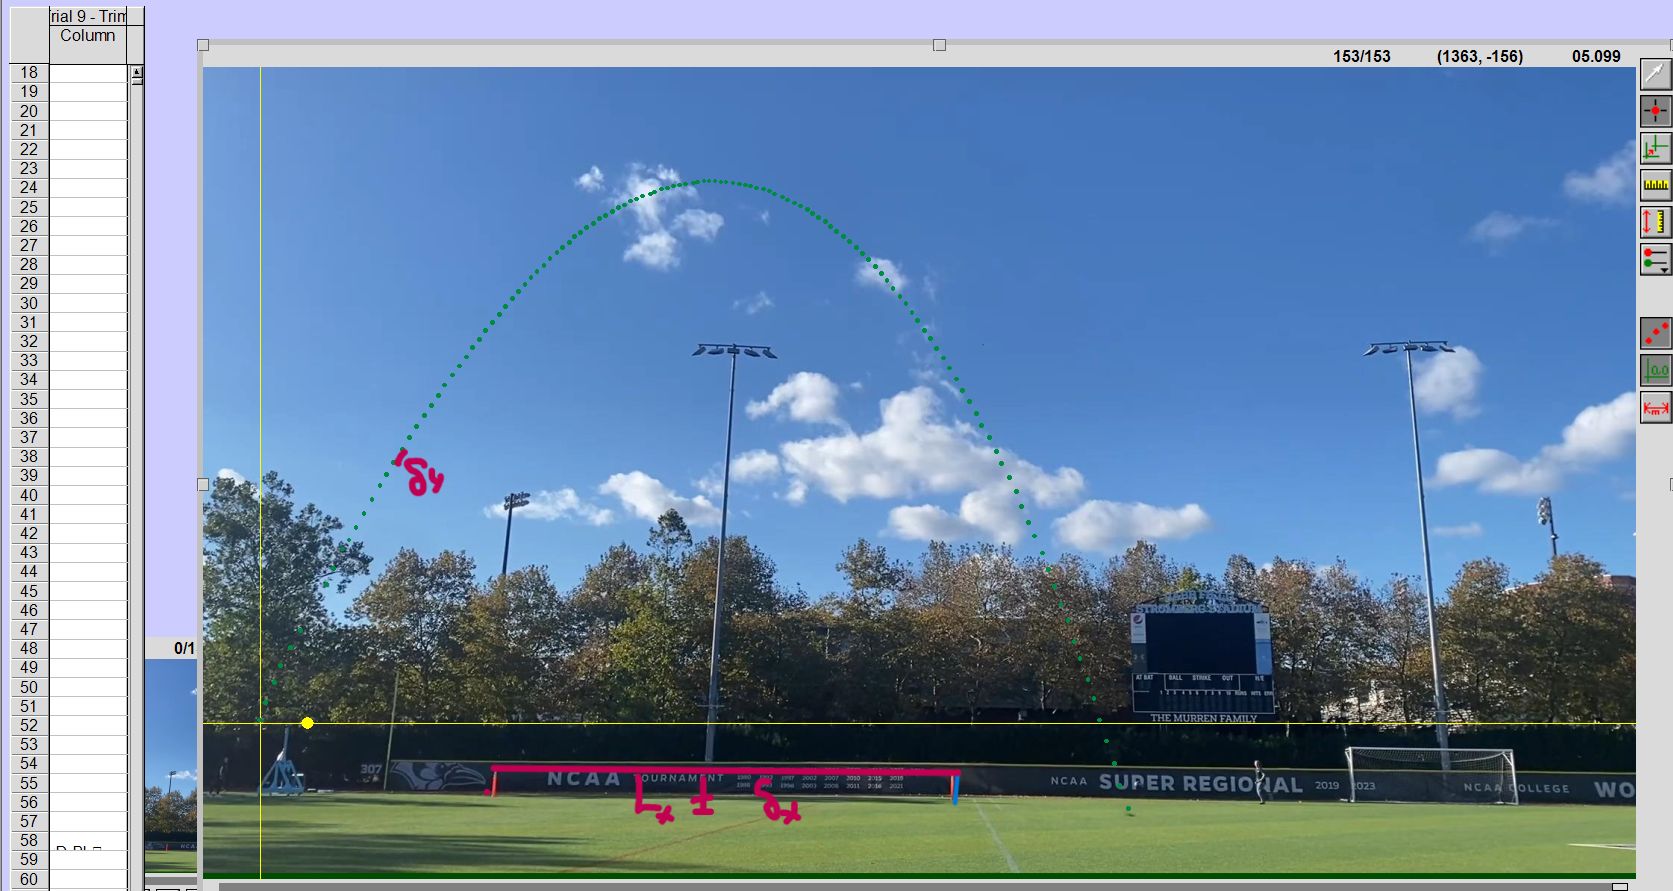

In [2]:
from IPython.display import Image, display
display(Image('images/Screenshot 2024-10-14 191626.png'))